In [36]:
import pandas as pd 
import numpy as np 

import scipy.stats as stats 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.compose import ColumnTransformer
from sklearn. model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [2]:
df=pd.read_csv(r"C:\Users\akash\Desktop\python project\ML\datasets\train.csv",usecols=["Survived","Age","Fare"])

In [3]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [4]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [5]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=["Survived"]),df["Survived"],test_size=0.2,random_state=42)


In [32]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

In [33]:
x_train

,Age,Fare
331,3.839452,28.5000
733,3.178054,13.0000
382,3.496508,7.9250
704,3.295837,7.8542
813,1.945910,31.2750
...,...,...
106,3.091042,7.6500
270,3.417689,31.0000
860,3.737670,14.1083
435,2.708050,120.0000


In [8]:
x_train.isnull().sum()

Age     140
Fare      0
dtype: int64

In [9]:
impt=SimpleImputer()
x_train['Age']=impt.fit_transform(x_train[["Age"]])


x_test['Age']=impt.transform(x_test[["Age"]])

In [10]:
x_train.isnull().sum()

Age     0
Fare    0
dtype: int64

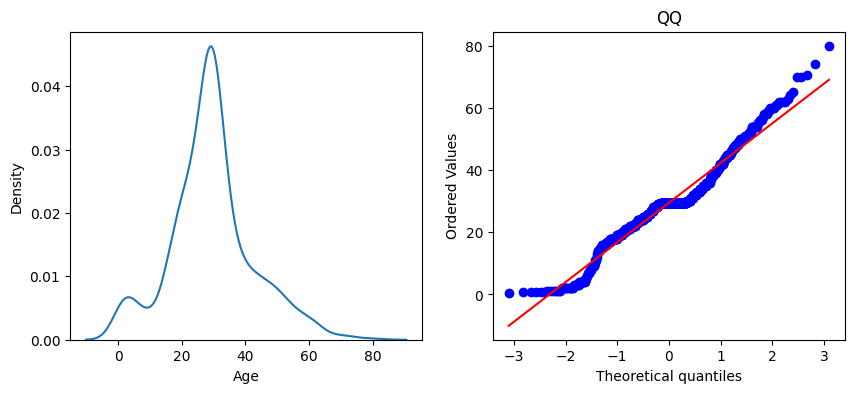

In [12]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
sns.kdeplot(data=x_train['Age'],ax=axes[0])
stats.probplot(x_train['Age'],dist="norm",plot=axes[1])

axes[1].set_title("QQ")

plt.show()


In [14]:
tnf=FunctionTransformer(np.log1p)
x_train["Age"]=tnf.fit_transform(x_train[["Age"]])
x_test["Age"]=tnf.transform(x_test[["Age"]])


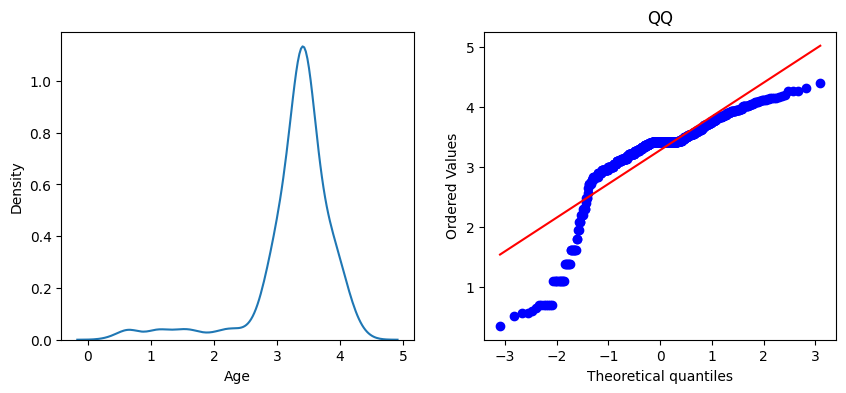

In [15]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
sns.kdeplot(data=x_train['Age'],ax=axes[0])
stats.probplot(x_train['Age'],dist="norm",plot=axes[1])

axes[1].set_title("QQ")

plt.show()


In [18]:
trf=ColumnTransformer(transformers=[(
"t1",FunctionTransformer(np.sqrt),["Age"]
)],remainder="passthrough"
)

In [24]:
x_train_sqrt=trf.fit_transform(x_train)
x_test_sqrt=trf.transform(x_test)

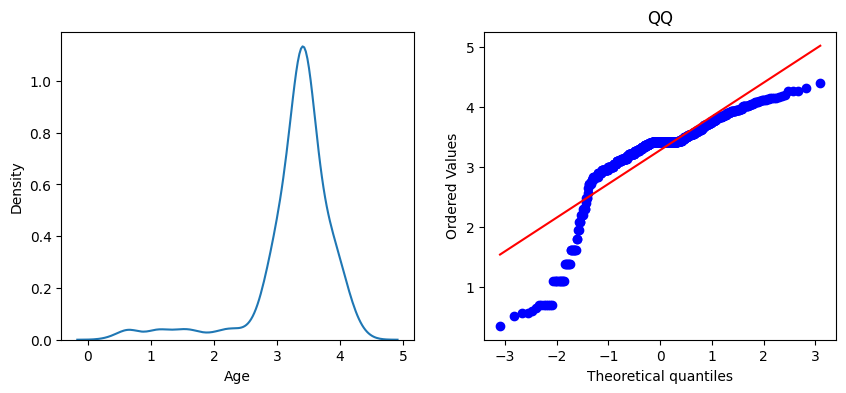

In [25]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
sns.kdeplot(data=x_train['Age'],ax=axes[0])
stats.probplot(x_train['Age'],dist="norm",plot=axes[1])

axes[1].set_title("QQ")

plt.show()


In [38]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
clf.fit(x_train_sqrt,y_train)
clf2.fit(x_train_sqrt,y_train)
pred=clf.predict(x_test_sqrt)
pred2=clf2.predict(x_test_sqrt)
print("Accuracy score of DT",accuracy_score(y_test,pred))
print("accuracy score",accuracy_score(y_test,pred))

Accuracy score of DT 0.6424581005586593
accuracy score 0.6424581005586593
